# Načtení dat

In [1]:
import pandas as pd
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import optuna

from plotly.subplots import make_subplots
from matplotlib import pyplot as plt
from mlforecast import MLForecast
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from statsforecast import StatsForecast
from statsforecast.models import Naive, HistoricAverage, WindowAverage

In [2]:
# Load dataset
df = pd.read_csv("data/dataset_ml.csv", sep=';', parse_dates=['date'], date_format='%d.%m.%Y')

df.head(10)

,region,date,price
0,praha,2019-03-31,73818
1,praha,2019-06-30,75162
2,praha,2019-09-30,77202
3,praha,2019-12-31,79382
4,stredocesky,2019-03-31,28777
5,stredocesky,2019-06-30,31328
6,stredocesky,2019-09-30,31846
7,stredocesky,2019-12-31,32882
8,jihocesky,2019-03-31,26028
9,jihocesky,2019-06-30,26896


In [3]:
# Prague only
only_prague = df[df["region"] == "praha"]
one_length = len(only_prague)
print(one_length)
print(only_prague)

24
    region       date   price
0    praha 2019-03-31   73818
1    praha 2019-06-30   75162
2    praha 2019-09-30   77202
3    praha 2019-12-31   79382
56   praha 2020-03-31   82409
57   praha 2020-06-30   84096
58   praha 2020-09-30   88315
59   praha 2020-12-31   88315
112  praha 2021-03-31   93413
113  praha 2021-06-30   96950
114  praha 2021-09-30  103196
115  praha 2021-12-31  109350
168  praha 2022-03-31  110995
169  praha 2022-06-30  114746
170  praha 2022-09-30  114792
171  praha 2022-12-31  110171
224  praha 2023-03-31  103549
225  praha 2023-06-30  103992
226  praha 2023-09-30  103859
227  praha 2023-12-31  103372
280  praha 2024-03-31  109246
281  praha 2024-06-30  114305
282  praha 2024-09-30  118362
283  praha 2024-12-31  121643


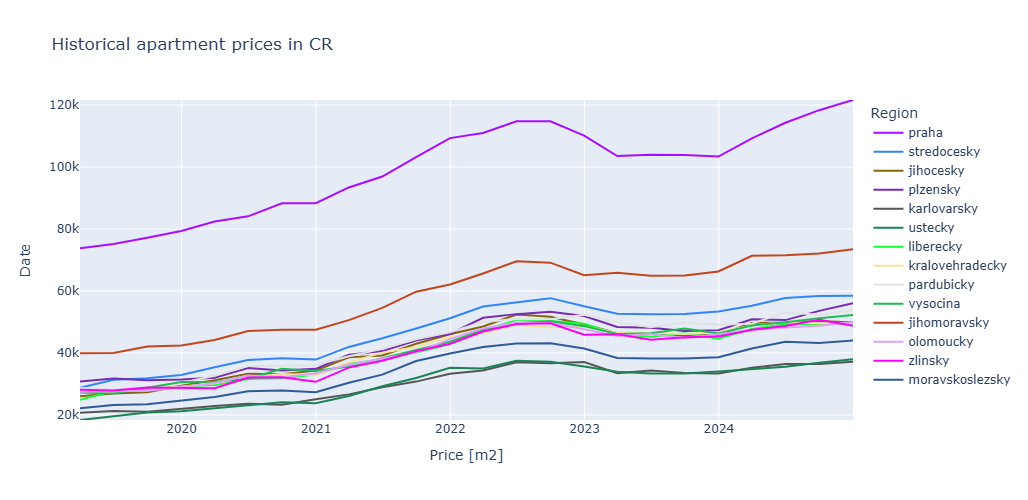

In [4]:
fig = px.line(
    df,
    x="date",
    y="price",
    color="region",
    title="Historical apartment prices in CR",
    color_discrete_sequence=px.colors.qualitative.Alphabet
)

fig.update_yaxes(range=[df["price"].min(), df["price"].max()])

fig.update_layout(
    autosize=True,
    height=500,
    xaxis_title="Price [m2]",
    yaxis_title="Date",
    legend_title="Region"
)

fig.show()

In [5]:
all_prices = df.pivot(index="date", columns="region", values="price").reset_index()
all_prices.describe()

region,date,jihocesky,jihomoravsky,karlovarsky,kralovehradecky,liberecky,moravskoslezsky,olomoucky,pardubicky,plzensky,praha,stredocesky,ustecky,vysocina,zlinsky
count,24,24.000000,24.000000,24.000000,24.00000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2022-02-13 18:00:00,41406.625000,58228.958333,30183.208333,40865.00000,40396.500000,34911.333333,40459.750000,43229.291667,43448.750000,99193.333333,46866.166667,30034.958333,41173.375000,40060.333333
min,2019-03-31 00:00:00,26028.000000,39865.000000,20701.000000,27075.00000,24875.000000,22170.000000,27515.000000,28214.000000,30769.000000,73818.000000,28777.000000,18357.000000,26948.000000,27871.000000
25%,2020-09-07 00:00:00,33230.750000,47354.750000,23549.750000,32652.50000,31802.250000,27537.000000,32601.750000,35761.000000,34728.500000,87260.250000,37832.250000,23662.750000,33558.500000,31711.500000
50%,2022-02-14 00:00:00,45710.500000,63519.500000,33311.500000,45609.00000,43760.500000,38222.000000,44611.000000,47488.500000,46640.000000,103460.500000,51836.500000,33369.500000,44886.500000,43609.500000
75%,2023-07-23 00:00:00,49282.500000,67018.250000,35501.500000,48294.00000,48081.250000,41576.250000,47732.500000,50212.750000,50995.750000,110377.000000,55122.250000,35282.750000,48702.000000,47064.750000
max,2024-12-31 00:00:00,52378.000000,73451.000000,37144.000000,50018.00000,50588.000000,44031.000000,49880.000000,53864.000000,56063.000000,121643.000000,58474.000000,37944.000000,52256.000000,50700.000000
std,NaN,8911.729271,11718.000395,6146.296325,8435.44919,8723.873302,7744.180259,8331.739336,8968.796485,8688.045506,14786.199164,10088.469396,6648.853693,8660.524669,8361.397068


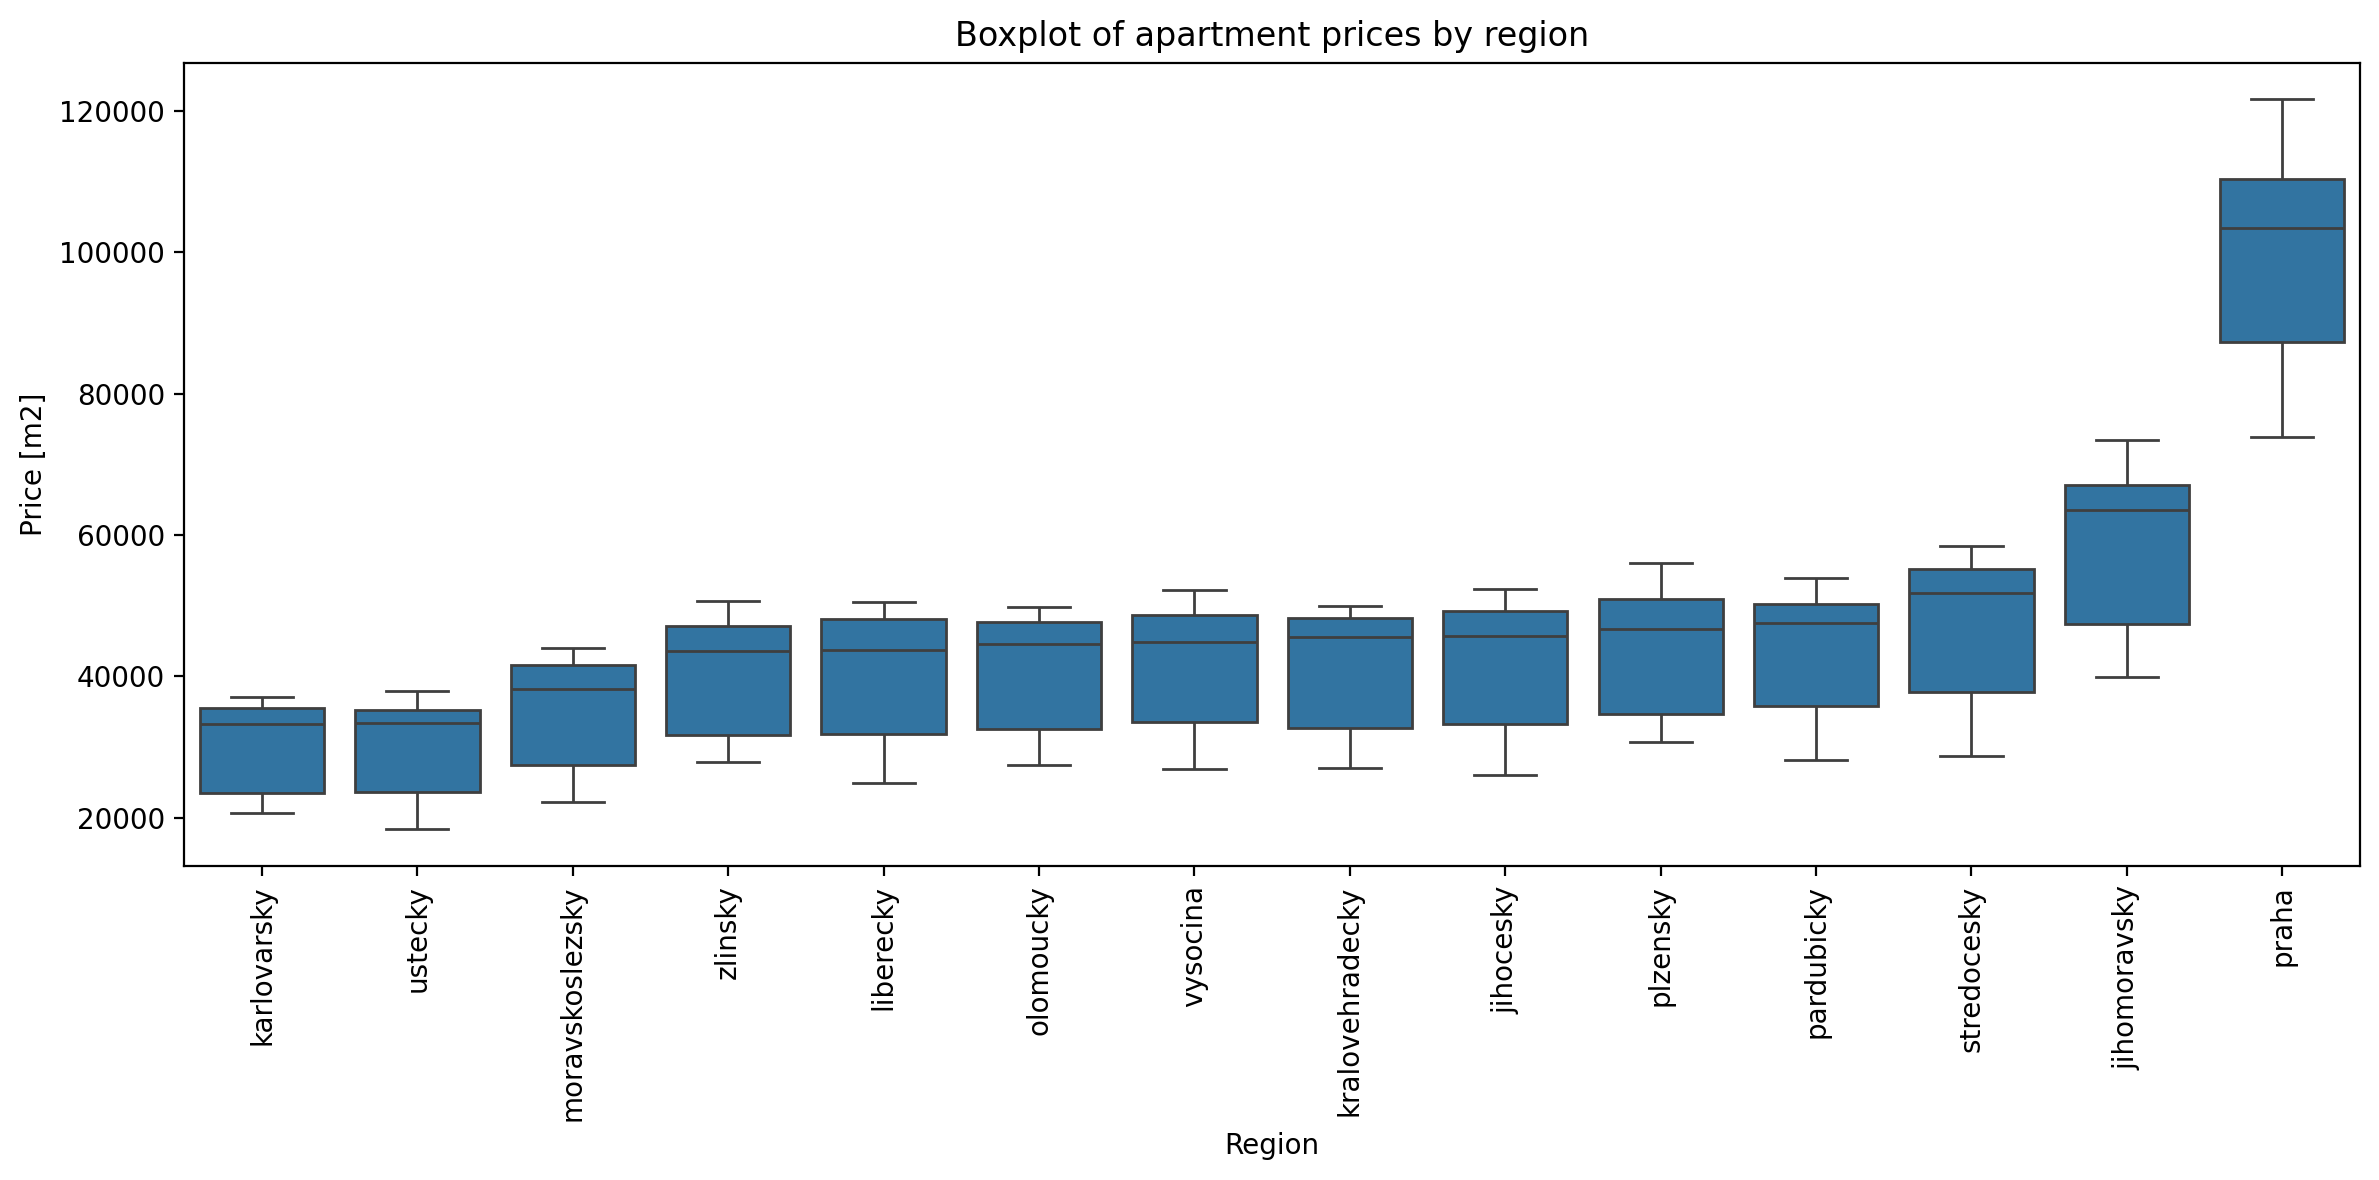

In [6]:
order = df.groupby("region")["price"].median().sort_values().index

plt.figure(figsize=(12, 6), dpi=200)
sns.boxplot(data=df, x="region", y="price", order=order)
plt.xticks(rotation=90)
plt.xlabel("Region")
plt.ylabel("Price [m2]")
plt.title("Boxplot of apartment prices by region")
plt.tight_layout()
plt.show()

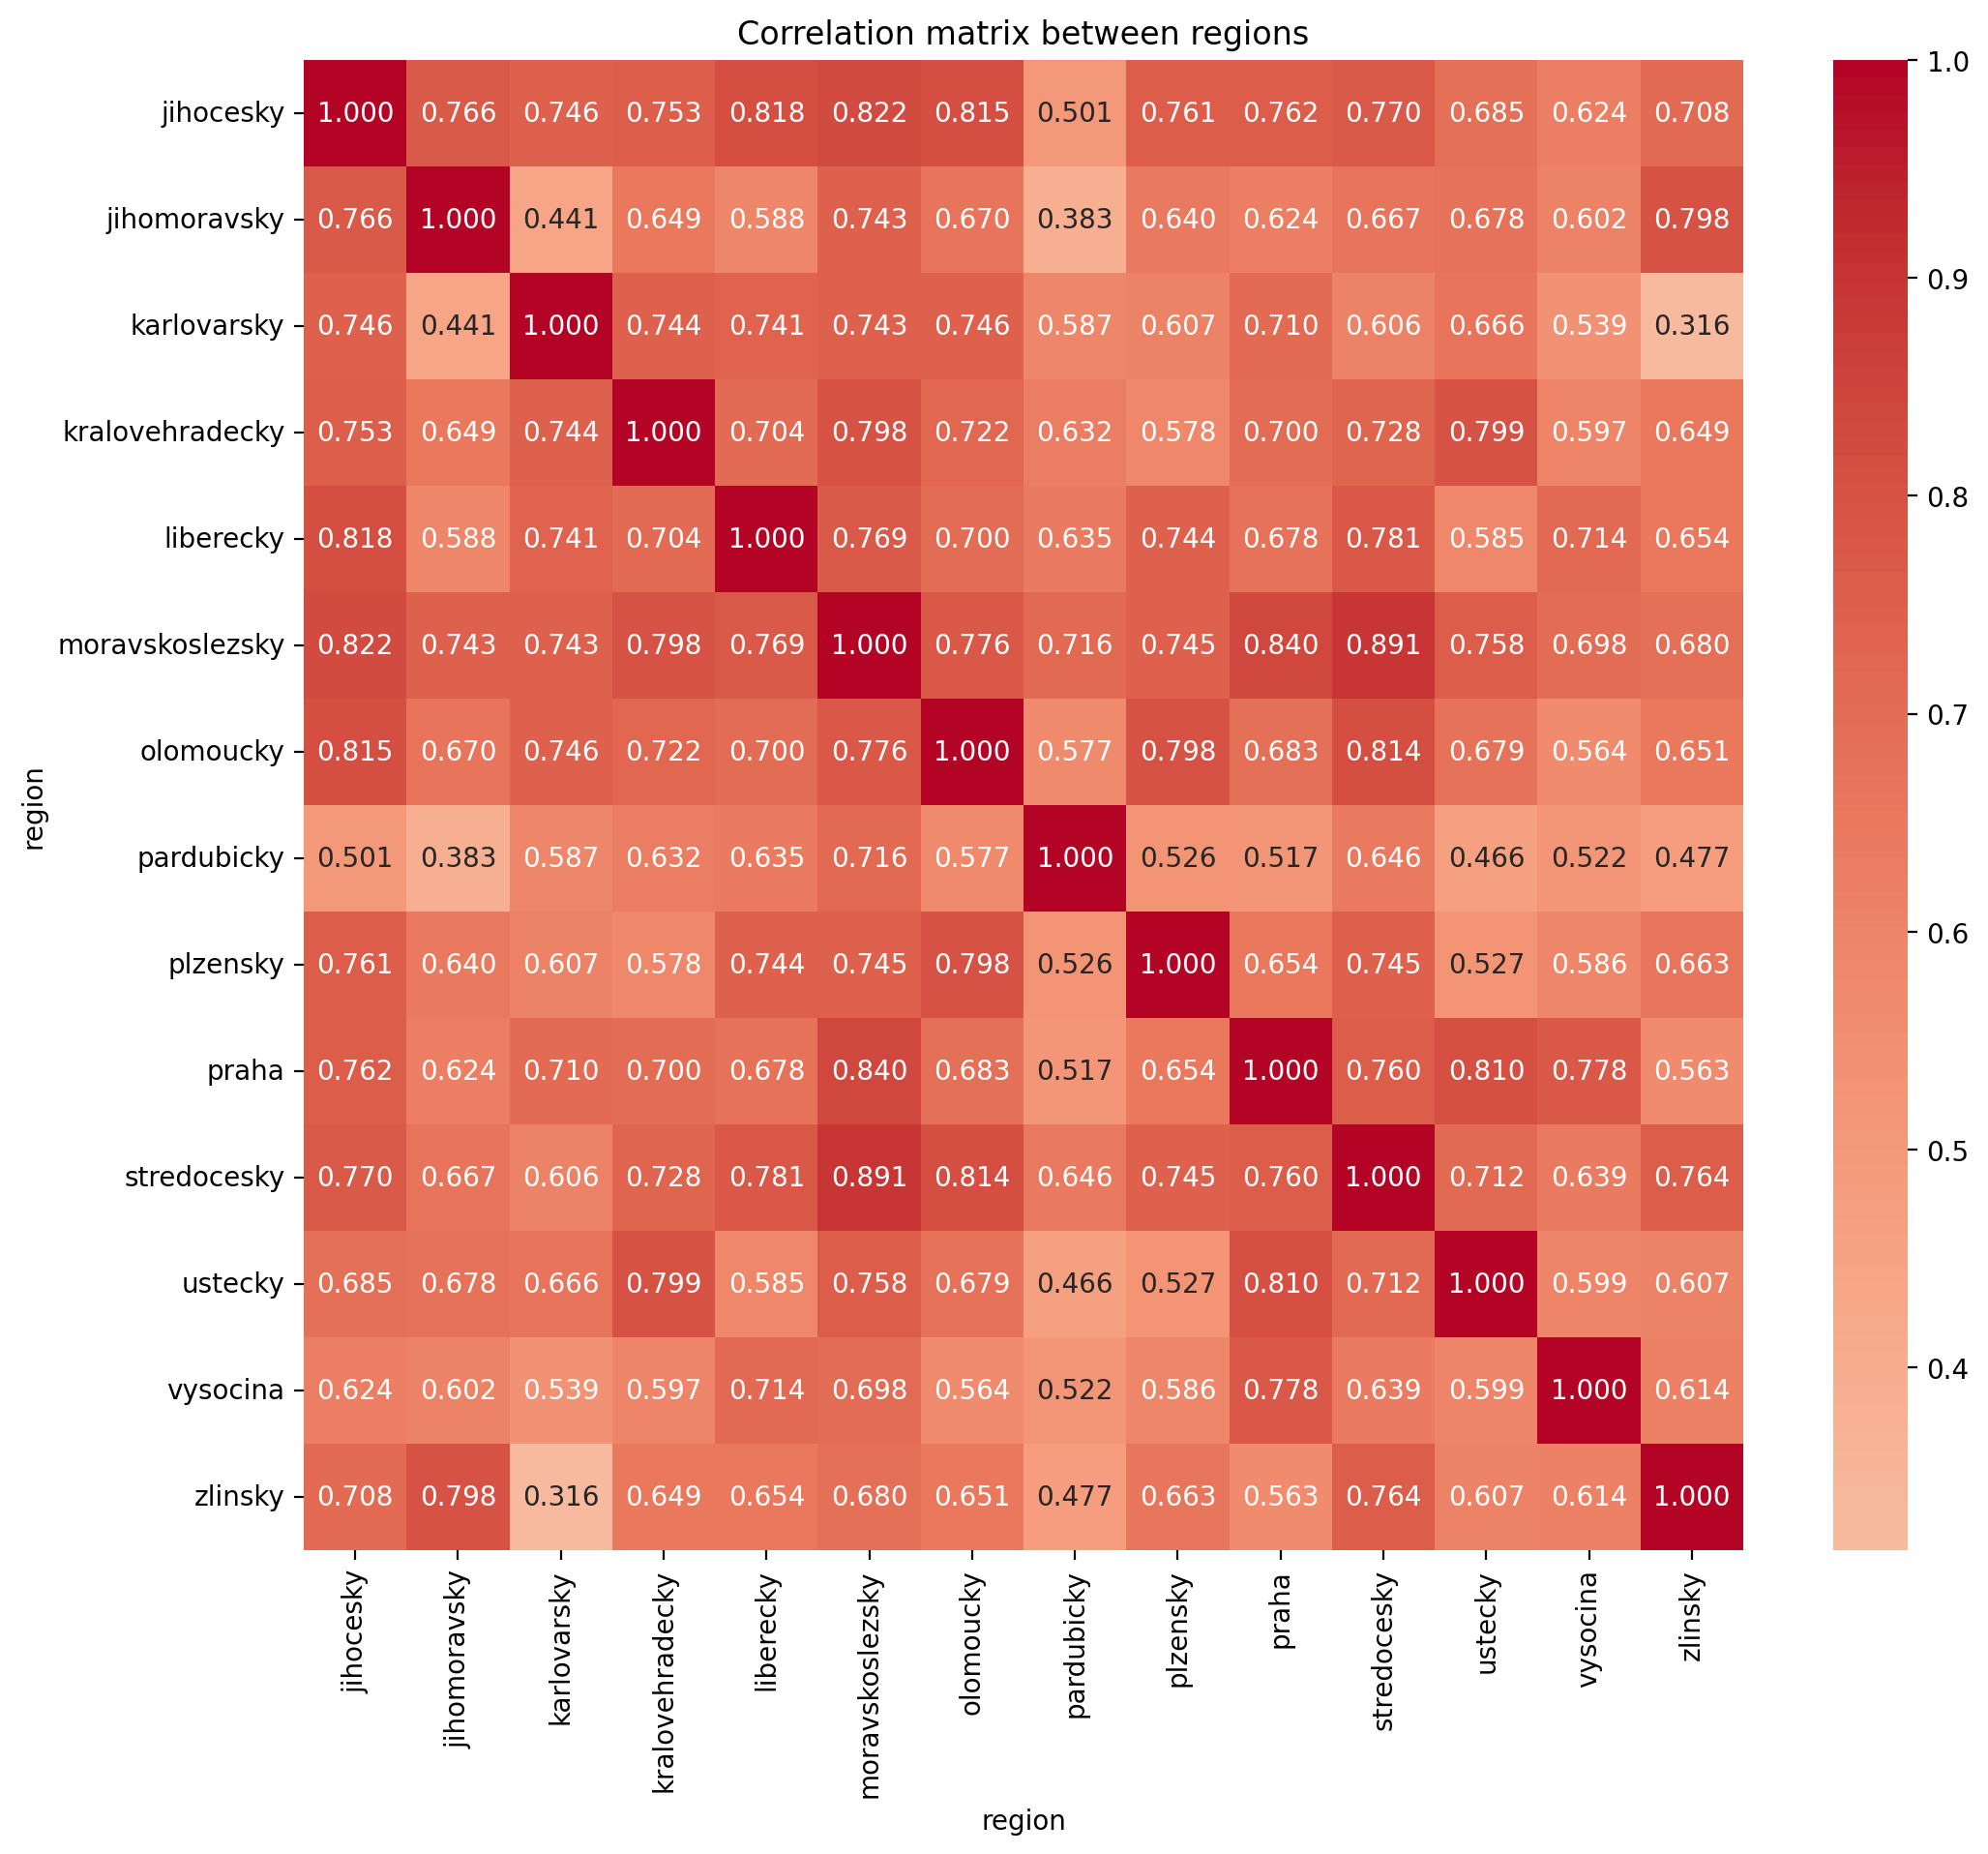

In [7]:
all_prices_diff = all_prices.set_index("date").diff().dropna()
corr_matrix = all_prices_diff.corr()

plt.figure(figsize=(12, 10), dpi=200)
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation matrix between regions")
plt.show()

# Model Evaluation

## Hyperparameters

In [8]:
lags = [1, 2, 3, 4] # last year
h = 1 # next quarter
step_size = 1

max_num_windows = (one_length - (max(lags) + h)) // step_size
print(max_num_windows)

19


## Random Forest Regressor & XGBoost Hyperparameter Tuning

In [9]:
def tune_model(model_class, param_func, n_trials=20):
    model_name = model_class.__name__
    print(f"Initializing tuning for: {model_name}...")

    def objective(trial):
        params = param_func(trial)
        
        model = model_class(**params)
        
        mlf_tune = MLForecast(
            models=[model],
            freq='QE',
            lags=lags
        )
        
        cv_results = mlf_tune.cross_validation(
            df=df, 
            h=h, 
            step_size=step_size,
            n_windows=max_num_windows,
            id_col='region',
            time_col='date', 
            target_col='price',
        )
        
        error = mean_absolute_error(cv_results['price'], cv_results[model_name])
        return error

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    
    print(f"Tuning {model_name} completed. Best MAE: {study.best_value:.2f}")
    return study.best_params

In [10]:
def xgb_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'random_state': 0,
        'n_jobs': -1
    }

def rf_params(trial):
    return {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 2, 10),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'random_state': 0,
        'n_jobs': -1
    }

best_params_xgb = tune_model(XGBRegressor, xgb_params, 20)
best_params_rf = tune_model(RandomForestRegressor, rf_params, 20)

[I 2026-03-03 12:59:01,241] A new study created in memory with name: no-name-0d541ba2-69c1-4596-9f0e-d54dfc80b353


Initializing tuning for: XGBRegressor...


[I 2026-03-03 12:59:02,881] Trial 0 finished with value: 2269.700927734375 and parameters: {'n_estimators': 214, 'max_depth': 4, 'learning_rate': 0.020321310435429844, 'subsample': 0.97436337922216, 'colsample_bytree': 0.7982443695490886}. Best is trial 0 with value: 2269.700927734375.
[I 2026-03-03 12:59:04,325] Trial 1 finished with value: 3422.73681640625 and parameters: {'n_estimators': 127, 'max_depth': 5, 'learning_rate': 0.015235112689467426, 'subsample': 0.5706146151425295, 'colsample_bytree': 0.6588885910114823}. Best is trial 0 with value: 2269.700927734375.
[I 2026-03-03 12:59:05,674] Trial 2 finished with value: 2034.4384765625 and parameters: {'n_estimators': 257, 'max_depth': 2, 'learning_rate': 0.05414466455736233, 'subsample': 0.7898211675966779, 'colsample_bytree': 0.9916750659031879}. Best is trial 2 with value: 2034.4384765625.
[I 2026-03-03 12:59:07,315] Trial 3 finished with value: 3614.22412109375 and parameters: {'n_estimators': 174, 'max_depth': 6, 'learning_rat

Tuning XGBRegressor completed. Best MAE: 2001.50
Initializing tuning for: RandomForestRegressor...


[I 2026-03-03 12:59:34,338] Trial 0 finished with value: 2427.9694592124133 and parameters: {'n_estimators': 260, 'max_depth': 10, 'min_samples_split': 4}. Best is trial 0 with value: 2427.9694592124133.
[I 2026-03-03 12:59:41,051] Trial 1 finished with value: 2552.8740480520996 and parameters: {'n_estimators': 261, 'max_depth': 9, 'min_samples_split': 6}. Best is trial 0 with value: 2427.9694592124133.
[I 2026-03-03 12:59:47,931] Trial 2 finished with value: 2496.866796660161 and parameters: {'n_estimators': 265, 'max_depth': 4, 'min_samples_split': 4}. Best is trial 0 with value: 2427.9694592124133.
[I 2026-03-03 12:59:54,954] Trial 3 finished with value: 2435.8922217197396 and parameters: {'n_estimators': 273, 'max_depth': 5, 'min_samples_split': 4}. Best is trial 0 with value: 2427.9694592124133.
[I 2026-03-03 12:59:59,212] Trial 4 finished with value: 2943.557585340445 and parameters: {'n_estimators': 155, 'max_depth': 10, 'min_samples_split': 10}. Best is trial 0 with value: 2427

Tuning RandomForestRegressor completed. Best MAE: 2261.30


## Training

In [11]:
best_xgb = XGBRegressor(**best_params_xgb, random_state=0)
best_rf = RandomForestRegressor(**best_params_rf, random_state=0)

mlf = MLForecast(
    models=[
        LinearRegression(),
        best_xgb,
        best_rf
    ],
    freq='QE',
    lags=lags,
)

sf = StatsForecast(
    models=[
        Naive(), 
        HistoricAverage(), 
        WindowAverage(window_size=max(lags))
    ],
    freq='QE',
)

cv_results_ml = mlf.cross_validation(
    df=df, 
    h=h, 
    step_size=step_size,
    n_windows=max_num_windows,
    id_col='region',
    time_col='date', 
    target_col='price',
)

cv_results_stat = sf.cross_validation(
    df=df,
    h=h, 
    step_size=step_size, 
    n_windows=max_num_windows,
    id_col='region',
    time_col='date', 
    target_col='price',
)

## Results Analysis

In [12]:
def eval_pd(df: pd.DataFrame, col_name: str) -> None:
    mae = mean_absolute_error(
        df["price"],
        df[col_name]
    )
    mae_percent = (mae / df["price"].mean()) * 100

    print("-" * 50)
    print(f"Results for {col_name}")
    print(f"MAE: {mae:.2f} CZK")
    print(f"MAE (%): {mae_percent:.2f} %")

In [13]:
for model in sf.models:
    eval_pd(cv_results_stat, model.alias)

for model in mlf.models:
    eval_pd(cv_results_ml, model)

--------------------------------------------------
Results for Naive
MAE: 1833.51 CZK
MAE (%): 3.78 %
--------------------------------------------------
Results for HistoricAverage
MAE: 9574.61 CZK
MAE (%): 19.76 %
--------------------------------------------------
Results for WindowAverage
MAE: 3884.76 CZK
MAE (%): 8.02 %
--------------------------------------------------
Results for LinearRegression
MAE: 1762.08 CZK
MAE (%): 3.64 %
--------------------------------------------------
Results for XGBRegressor
MAE: 2001.50 CZK
MAE (%): 4.13 %
--------------------------------------------------
Results for RandomForestRegressor
MAE: 2261.30 CZK
MAE (%): 4.67 %


## Graphical Visualization

In [14]:
def show_graph(df: pd.DataFrame, forecasts: pd.DataFrame) -> None:
    regione = df["region"].unique()

    model_columns = [
        col for col in forecasts.columns
        if col not in ["region", "date"]
    ]

    colors = px.colors.qualitative.Plotly
    model_colors = {
        model: colors[i % len(colors)]
        for i, model in enumerate(model_columns)
    }

    fig = make_subplots(
        rows=len(regione),
        cols=1,
        shared_xaxes=False,
        vertical_spacing=0.02,
        subplot_titles=regione
    )

    trace_map = []

    for i, region in enumerate(regione, start=1):

        real = df[df["region"] == region]
        preds = forecasts[forecasts["region"] == region]

        # Actual
        fig.add_trace(
            go.Scatter(
                x=real["date"],
                y=real["price"],
                mode="lines",
                name="Actual",
                line=dict(color="black", width=4),
                showlegend=(i == 1)
            ),
            row=i,
            col=1
        )

        trace_map.append(("Actual", len(fig.data)-1))

        # Models
        for model in model_columns:
            if model in preds.columns:
                fig.add_trace(
                    go.Scatter(
                        x=preds["date"],
                        y=preds[model],
                        mode="lines",
                        name=model,
                        line=dict(color=model_colors[model]),
                        showlegend=(i == 1)
                    ),
                    row=i,
                    col=1
                )

                trace_map.append((model, len(fig.data)-1))

    # DROPDOWN MENU
    buttons = []

    for model in model_columns:
        visibility = []

        for name, idx in trace_map:
            if name == "Actual" or name == model:
                visibility.append(True)
            else:
                visibility.append(False)

        buttons.append(
            dict(
                label=model,
                method="update",
                args=[{"visible": visibility}]
            )
        )

    buttons.insert(
        0,
        dict(
            label="All models",
            method="update",
            args=[{"visible": [True] * len(trace_map)}]
        )
    )

    fig.update_layout(
        height=500 * len(regione),
        width=1100,
        legend=dict(
            orientation="v",
            x=1.02,
            xanchor="left",
            y=0.99,
            yanchor="top"
        ),
        updatemenus=[
            dict(
                buttons=buttons,
                direction="down",
                showactive=True,
                x=1.02,
                xanchor="left",
                y=1.0,
                yanchor="top"
            )
        ]
    )

    fig.show()

In [15]:
ml_forecasts = cv_results_ml.drop(columns=["price", "cutoff"])
stat_forecasts = cv_results_stat.drop(columns=["price", "cutoff"])

combined_forecasts = pd.merge(
    ml_forecasts,
    stat_forecasts,
    on=["region", "date"],
    how="inner"
)

show_graph(df, combined_forecasts)

# Prediction

In [16]:
mlf.fit(
    df=df,
    id_col='region',
    time_col='date',
    target_col='price'
)

predictions_ml = mlf.predict(h=4)

## Graph Vizualization

In [17]:
show_graph(df, predictions_ml)